# The 'Largest Stock Profit or Loss' Puzzle: Efficient Computation in Python

**Inspired by** the original SQL puzzle from [ryxcommar.com](https://ryxcommar.com/2019/08/05/a-cool-sql-problem-avoiding-for-loops/).

---

## The Problem

> You have a table of trading days (with no gaps) and close prices for a stock.
> Find the **highest profit** and **lowest loss** you could have made if you bought the stock at one close price and sold it at another close price — exactly two transactions.
> **You cannot sell before you buy.**

In plain English: if you could see the future, what is the best (and worst) trade you could have made?

This notebook demonstrates **three approaches** of increasing efficiency:

1. **SQL self-join** — clear and expressive, but expensive on memory (O(n²) rows)
2. **pandas `merge` self-join** — same idea, pure Python/pandas
3. **NumPy vectorised `cummax`/`cummin`** — blazing fast, O(n) time and memory

We then extend the puzzle to ask: *what if you had to hold the stock for at least N days?*

---

## Stock: NVIDIA (NVDA), 5 Years of Daily Close Prices

## 1. Setup & Data Download

We use `yfinance` to pull 5 years of adjusted closing prices for a list of tickers. 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import duckdb          # In-process SQL engine that reads pandas DataFrames natively
import warnings
from datetime import date

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
tickers_to_download = ['NVDA', "DPZ", "GOOG", "XOM", "JPM", "TSLA", "PYPL", "MTCH"]
# We dynamically set the date range. 'date.today()' gets the current date.
end_date = date.today()
# The start date is set to January 1st, five years prior to the current year.
start_date = date(end_date.year - 5, 1, 1)




print(f"\nDownloading historical stock data from {start_date} to {end_date}...")
# This is the main function call to yfinance. It downloads all the data we need in one go.
stock_prices = (yf.download(
    tickers_to_download, # The list of tickers we want.
    start=start_date,    # The start of our historical date range.
    end=date.today(),      # The end of our date range.
    # period="5y",
    auto_adjust=False,   # We set this to False because we want to specifically select the 'Adj Close' column.
    progress=False       # Hides the download progress bar for a cleaner output.
)['Adj Close'] # From the downloaded data, we select only the 'Adj Close' (Adjusted Close) price.
               # This price is adjusted for dividends and stock splits, making it the most accurate
               # price to use for calculating historical returns.
.reset_index()
)
print("Download complete.")

stock_prices.head()
# stock_prices.info()


Download complete.


Ticker,Date,DPZ,GOOG,JPM,MTCH,NVDA,PYPL,TSLA,XOM
0,2021-01-04,356.211823,85.708344,110.051910,145.618393,13.076725,230.686646,243.256668,33.693787
1,2021-01-05,357.938873,86.337173,110.650726,145.977753,13.367159,233.660751,245.036667,35.317589
2,2021-01-06,361.252289,86.057961,115.846443,144.540222,12.579123,225.623718,251.993332,36.218796
3,2021-01-07,359.675415,88.634827,119.650734,148.474030,13.306577,233.790054,272.013336,36.502960
4,2021-01-08,364.969238,89.624695,119.782822,147.434708,13.239515,241.170609,293.339996,36.908905


### Visualise the price history

Before solving the puzzle it is always worth eyeballing the data. NVDA has been one of the most dramatic stocks of the 2020s.

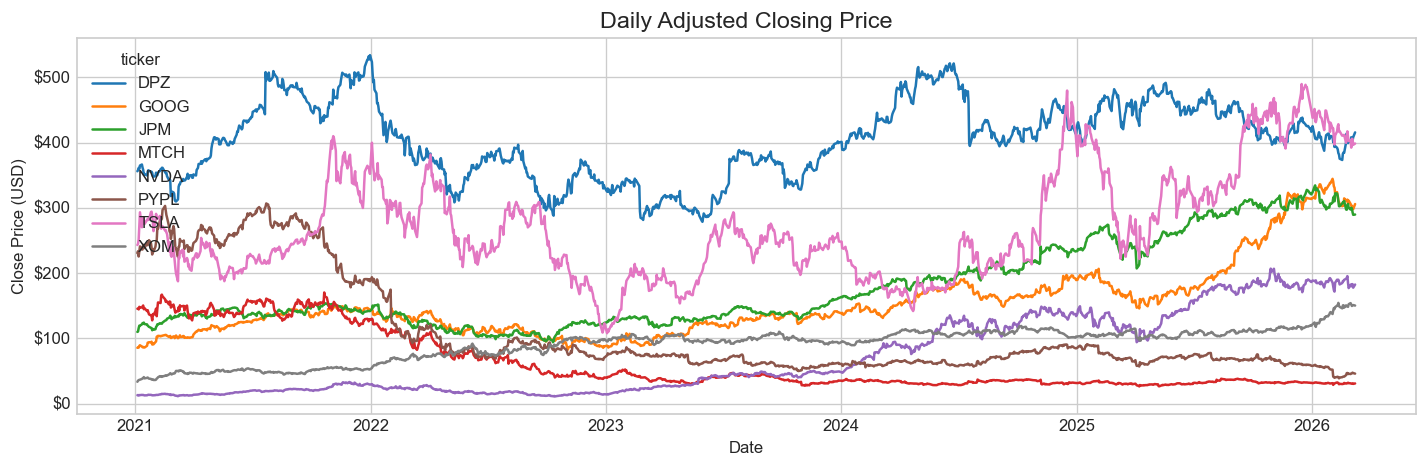

In [3]:
# Melt wide → long
df_long = stock_prices.melt(id_vars="Date", 
                    var_name="ticker", 
                    value_name="close")


fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(
    data=df_long,
    x="Date",
    y="close",
    hue="ticker",   # one line per stock, auto-colored + legend
    linewidth=1.5,
    ax=ax
)

ax.set_title("Daily Adjusted Closing Price", fontsize=14)
ax.set_ylabel("Close Price (USD)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()


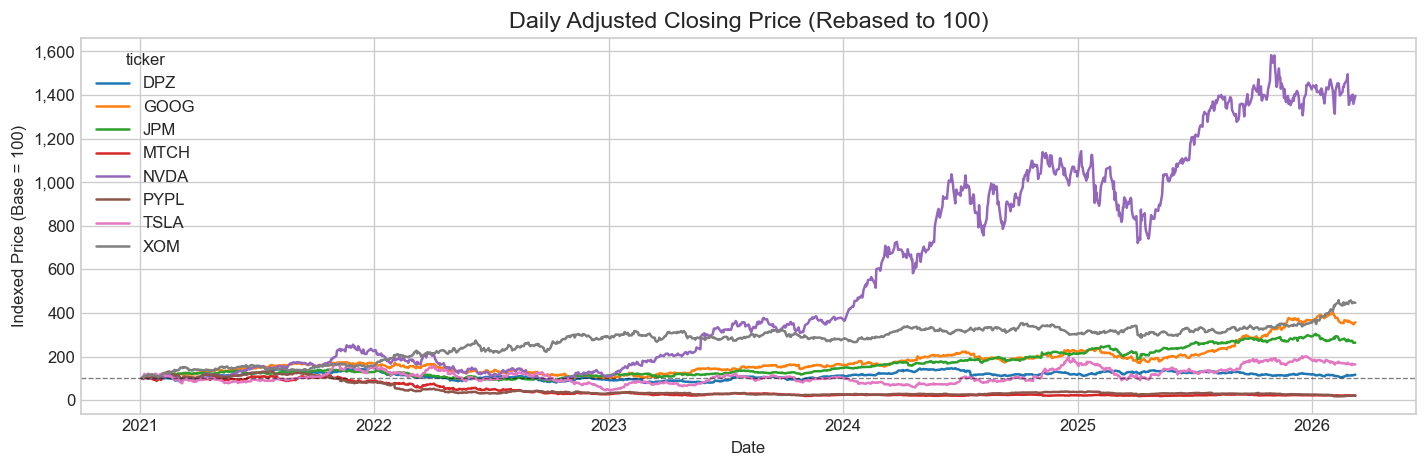

In [4]:

# Rebase to 100
df_long["close_rebased"] = (
    df_long.groupby("ticker")["close"]
    .transform(lambda s: s / s.iloc[0] * 100)
)

fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(
    data=df_long,
    x="Date",
    y="close_rebased",
    hue="ticker",
    linewidth=1.5,
    ax=ax
)

ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Daily Adjusted Closing Price (Rebased to 100)", fontsize=14)
ax.set_ylabel("Indexed Price (Base = 100)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

---

## 2. Approach 1: SQL Self-Join with DuckDB

### The Intuition

The clearest way to think about this problem is as a self-join. Imagine printing the price table twice —
one copy labelled "buy" and one labelled "sell" — then joining every buy-day to every sell-day that
comes **after** it.

For each such pair, `change = sell_price - buy_price`. The maximum change is your best possible trade;
the minimum is your worst.

```
buy_date   buy_price | sell_date   sell_price | change
──────────────────────────────────────────────────────
2020-01-02    $5.90  | 2020-01-03    $6.10    |  +$0.20
2020-01-02    $5.90  | 2020-01-06    $5.50    |  -$0.40
...           ...      ...           ...         ...
```

> **Warning on scale:** For ~1,260 trading days (5 years), the self-join produces roughly
> 1,260² / 2 ≈ **794,000 rows**. Manageable for one stock, but it would explode for thousands.

### Why DuckDB?

[DuckDB](https://duckdb.org/) is an in-process analytical SQL engine that reads pandas DataFrames
natively — no server, no CSV export needed. It is the closest Python equivalent to dplyr's expressive
chaining style.

In [5]:
# DuckDB can reference a pandas DataFrame directly in SQL by its variable name.
# We alias 'sp' as both 'buy' and 'sell' to perform a self-join.

# DuckDB cannot compare tz-aware datetimes — strip timezone before querying
sp = df_long.copy()
sp["Date"] = sp["Date"].dt.tz_localize(None)


sql_result = duckdb.query("""
    -- STEP-BY-STEP: Split complex self-join into readable phases
    
    WITH 
    -- PHASE 1: Generate ALL possible buy/sell pairs for valid trades
    -- Creates N² combinations but filters sell.Date > buy.Date upfront
    buy_sell_pairs AS (
        SELECT
            buy.ticker,                    -- Stock symbol
            buy.Date  AS buy_date,         -- When we "bought"
            sell.Date AS sell_date,        -- When we "sold" (must be LATER)
            buy.close AS buy_price,        -- Buy price
            sell.close AS sell_price,      -- Sell price  
            sell.close - buy.close AS gain -- Profit/loss for THIS pair
            
        FROM sp AS buy                      -- Every row = potential BUY
        INNER JOIN sp AS sell              -- Every row = potential SELL
            ON  buy.ticker = sell.ticker   -- Same stock
            AND sell.Date > buy.Date       -- CRITICAL: sell AFTER buy
        
        -- Result: One row per valid (buy_date, sell_date) trade opportunity
    )
    
    -- PHASE 2: From all possible trades, find BEST + WORST per stock
    SELECT
        ticker,
        
        -- BEST trade: highest profit across ALL buy/sell combinations
        MAX(gain)                                    AS largest_gain,
        ARG_MAX(buy_date, gain)                      AS gain_buy_date, 
        ARG_MAX(sell_date, gain)                     AS gain_sell_date,
        
        -- WORST trade: biggest loss across ALL combinations  
        MIN(gain)                                    AS largest_loss,
        ARG_MIN(buy_date, gain)                      AS loss_buy_date,
        ARG_MIN(sell_date, gain)                     AS loss_sell_date

    FROM buy_sell_pairs                    -- Work with pre-filtered trade pairs
    GROUP BY ticker                        -- One row per stock
    ORDER BY ticker ASC                    -- Alphabetical order
""").df()

sql_result[["largest_gain", "largest_loss"]] = (
    sql_result[["largest_gain", "largest_loss"]].round(2)
)

sql_result

,ticker,largest_gain,gain_buy_date,gain_sell_date,largest_loss,loss_buy_date,loss_sell_date
0,DPZ,242.87,2023-05-31,2024-06-18,-255.37,2021-12-31,2023-05-31
1,GOOG,261.85,2022-11-03,2026-02-02,-66.67,2021-11-18,2022-11-03
2,JPM,240.34,2022-10-11,2026-01-06,-67.00,2025-02-18,2025-04-04
3,MTCH,43.28,2021-08-17,2021-10-21,-143.93,2021-10-21,2025-04-08
4,NVDA,195.82,2022-10-14,2025-10-29,-55.10,2025-01-06,2025-04-04
5,PYPL,82.00,2021-03-08,2021-07-23,-267.93,2021-07-23,2026-02-12
6,TSLA,381.78,2023-01-03,2025-12-16,-301.87,2021-11-04,2023-01-03
7,XOM,120.84,2021-01-04,2026-02-11,-22.54,2024-10-07,2025-04-10


---

## 3. Approach 2: pandas `merge` Self-Join (Method Chaining)

Method chaining keeps each transformation as a separate step that flows into the next 



```python
# Python (pandas method chaining)
stock_prices
  .merge(...)        # inner_join
  .query(...)        # filter
  .assign(...)       # mutate
  .groupby(...)
  .agg(...)          # summarize
```

In [6]:
# pandas merge Self-Join — method chaining style
# Each method returns a DataFrame, so we can chain them without temporary variables.


def get_best_worst(g):
    best_idx = g["change"].idxmax()
    worst_idx = g["change"].idxmin()
    return pd.Series({
        "largest_gain":    round(g.loc[best_idx,  "change"], 2),
        "gain_buy_date":   g.loc[best_idx,  "Date"],
        "gain_sell_date":  g.loc[best_idx,  "Date_future"],
        "largest_loss":    round(g.loc[worst_idx, "change"], 2),
        "loss_buy_date":   g.loc[worst_idx, "Date"],
        "loss_sell_date":  g.loc[worst_idx, "Date_future"],
    })

merge_result = (
    sp
    .merge(sp, on="ticker", suffixes=("", "_future"))
    .query("Date_future > Date")
    .assign(change=lambda df: df["close_future"] - df["close"])
    .groupby("ticker", as_index=False)
    .apply(get_best_worst)
    .reset_index(drop=True)
)

merge_result


,ticker,largest_gain,gain_buy_date,gain_sell_date,largest_loss,loss_buy_date,loss_sell_date
0,DPZ,242.87,2023-05-31,2024-06-18,-255.37,2021-12-31,2023-05-31
1,GOOG,261.85,2022-11-03,2026-02-02,-66.67,2021-11-18,2022-11-03
2,JPM,240.34,2022-10-11,2026-01-06,-67.00,2025-02-18,2025-04-04
3,MTCH,43.28,2021-08-17,2021-10-21,-143.93,2021-10-21,2025-04-08
4,NVDA,195.82,2022-10-14,2025-10-29,-55.10,2025-01-06,2025-04-04
5,PYPL,82.00,2021-03-08,2021-07-23,-267.93,2021-07-23,2026-02-12
6,TSLA,381.78,2023-01-03,2025-12-16,-301.87,2021-11-04,2023-01-03
7,XOM,120.84,2021-01-04,2026-02-11,-22.54,2024-10-07,2025-04-10


---

## 4. Approach 3: Vectorised NumPy (`cummax` / `cummin`) — The Fast Way

### Why is the self-join slow?

The self-join is O(n²): for 1,260 trading days it creates ~794,000 rows.
For 10,000 stocks it would need billions of rows — completely infeasible.

### The key insight: cumulative max/min

Instead of comparing every pair of dates, we do a single backward pass through the data:

1. **Sort by descending date** (most recent first)
2. **Take `cummax(close)`** — at each row this gives the highest price from *this day forwards*
3. **Best gain from any day** = `future_max_price − today_price`
4. **Worst loss from any day** = `future_min_price − today_price`

#### Toy example 

```
Prices (chronological):      41, 43, 47, 42, 45, 39, 38, 41
Reversed:                    41, 38, 39, 45, 42, 47, 43, 41
cummax of reversed:          41, 41, 41, 45, 45, 47, 47, 47
Re-reverse (= future max):   47, 47, 47, 45, 45, 41, 41, 41
                              ^-- buy at 41, sell at 47, gain = 6
```

This is **O(n) time and O(n) memory** — roughly 1000x faster than the self-join.

```

In [7]:
# ------- Toy example first — make sure we understand the mechanics -------

x = np.array([41, 43, 47, 42, 45, 39, 38, 41], dtype=float)

# np.maximum.accumulate is the vectorised C-level equivalent of R's cummax().
# Running it on the REVERSED array gives us the rolling max from each day FORWARD.
future_max = np.maximum.accumulate(x[::-1])[::-1]
future_min = np.minimum.accumulate(x[::-1])[::-1]

print("Prices:     ", x)
print("Future max: ", future_max)
print("Future min: ", future_min)
print()
print(f"Best possible gain : {np.max(future_max - x):.0f}  (matches R article: 6)")
print(f"Worst possible loss: {np.min(future_min - x):.0f}  (matches R article: -9)")

Prices:      [41. 43. 47. 42. 45. 39. 38. 41.]
Future max:  [47. 47. 47. 45. 45. 41. 41. 41.]
Future min:  [38. 38. 38. 38. 38. 38. 38. 41.]

Best possible gain : 6  (matches R article: 6)
Worst possible loss: -9  (matches R article: -9)


In [10]:
sp

,Date,ticker,close,close_rebased
0,2021-01-04,DPZ,356.211823,100.000000
1,2021-01-05,DPZ,357.938873,100.484838
2,2021-01-06,DPZ,361.252289,101.415019
3,2021-01-07,DPZ,359.675415,100.972341
4,2021-01-08,DPZ,364.969238,102.458485
...,...,...,...,...
10395,2026-03-03,XOM,151.830002,450.617212
10396,2026-03-04,XOM,149.820007,444.651737
10397,2026-03-05,XOM,150.759995,447.441530
10398,2026-03-06,XOM,151.210007,448.777124


In [11]:
def compute_best_worst(group: pd.Series):
    prices = group.values
    rev = prices[::-1]
    future_max = np.maximum.accumulate(rev)[::-1]
    future_min = np.minimum.accumulate(rev)[::-1]

    gain_buy_idx  = np.argmax(future_max - prices)
    gain_sell_idx = np.argmax(prices[gain_buy_idx:]) + gain_buy_idx

    loss_buy_idx  = np.argmin(future_min - prices)
    loss_sell_idx = np.argmin(prices[loss_buy_idx:]) + loss_buy_idx

    return pd.Series({
        "largest_gain":   round(float(future_max[gain_buy_idx]  - prices[gain_buy_idx]),  2),
        "gain_buy_date":  group.index[gain_buy_idx],
        "gain_sell_date": group.index[gain_sell_idx],
        "largest_loss":   round(float(future_min[loss_buy_idx]  - prices[loss_buy_idx]),  2),
        "loss_buy_date":  group.index[loss_buy_idx],
        "loss_sell_date": group.index[loss_sell_idx],
    })

vectorised_result = (
    sp
    .sort_values(["ticker", "Date"])
    .groupby("ticker")
    .apply(lambda g: compute_best_worst(g.set_index("Date")["close"]))
    .reset_index()
)

vectorised_result

,ticker,largest_gain,gain_buy_date,gain_sell_date,largest_loss,loss_buy_date,loss_sell_date
0,DPZ,242.87,2023-05-31,2024-06-18,-255.37,2021-12-31,2023-05-31
1,GOOG,261.85,2022-11-03,2026-02-02,-66.67,2021-11-18,2022-11-03
2,JPM,240.34,2022-10-11,2026-01-06,-67.00,2025-02-18,2025-04-04
3,MTCH,43.28,2021-08-17,2021-10-21,-143.93,2021-10-21,2025-04-08
4,NVDA,195.82,2022-10-14,2025-10-29,-55.10,2025-01-06,2025-04-04
5,PYPL,82.00,2021-03-08,2021-07-23,-267.93,2021-07-23,2026-02-12
6,TSLA,381.78,2023-01-03,2025-12-16,-301.87,2021-11-04,2023-01-03
7,XOM,120.84,2021-01-04,2026-02-11,-22.54,2024-10-07,2025-04-10


---

## 5. Visualising the Opportunity: Future Max & Min Overlaid on Price

For each trading day, we can ask two questions:
- "If I buy today, what is the highest price NVDA will ever reach before the end of the window?"
- "If I buy today, what is the lowest price it could fall to?"

The gap between the future max and today's price is the **green zone** (upside).
The gap between today's price and the future min is the **red zone** (downside).

In [13]:
def annotate(group):
    group = group.sort_values("Date").copy()
    p = group["close"].values
    rev = p[::-1]
    group["highest_future"] = np.maximum.accumulate(rev)[::-1]
    group["lowest_future"]  = np.minimum.accumulate(rev)[::-1]
    group["potential_gain"] = group["highest_future"] - group["close"]
    group["potential_loss"] = group["lowest_future"]  - group["close"]
    return group

prices_annotated = sp.groupby("ticker", group_keys=False).apply(annotate)

prices_annotated.head()



,Date,ticker,close,close_rebased,highest_future,lowest_future,potential_gain,potential_loss
0,2021-01-04,DPZ,356.211823,100.000000,534.112122,278.737549,177.900299,-77.474274
1,2021-01-05,DPZ,357.938873,100.484838,534.112122,278.737549,176.173248,-79.201324
2,2021-01-06,DPZ,361.252289,101.415019,534.112122,278.737549,172.859833,-82.514740
3,2021-01-07,DPZ,359.675415,100.972341,534.112122,278.737549,174.436707,-80.937866
4,2021-01-08,DPZ,364.969238,102.458485,534.112122,278.737549,169.142883,-86.231689


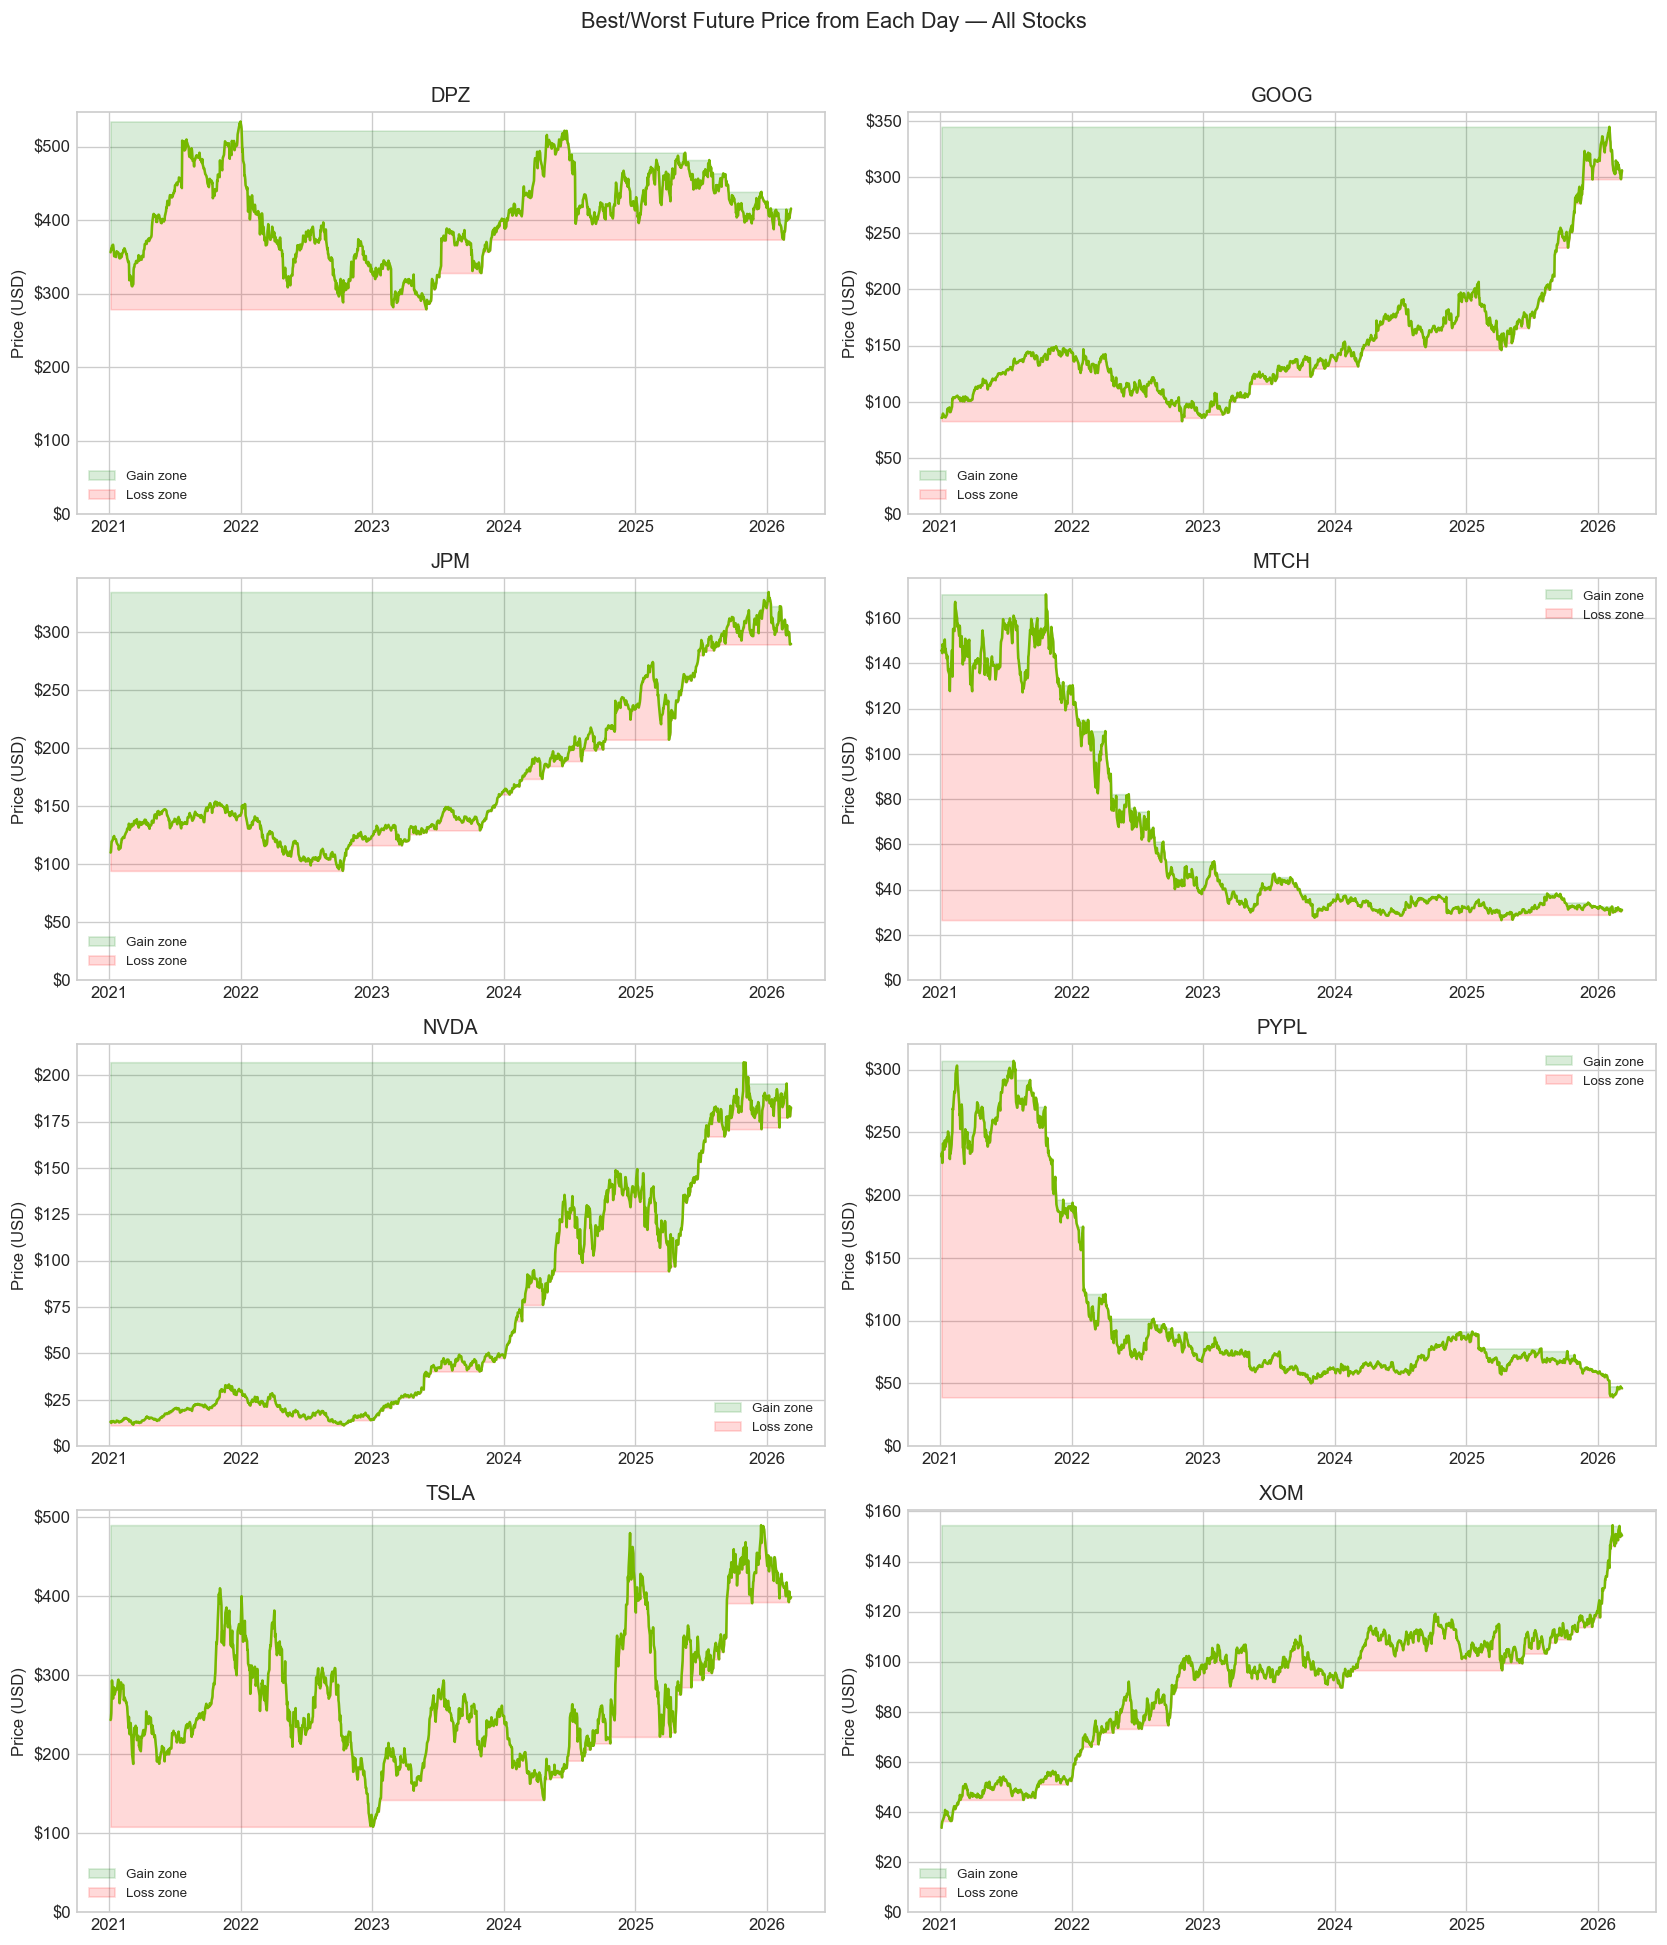

In [15]:
tickers = prices_annotated["ticker"].unique()
n_cols = 2
n_rows = int(np.ceil(len(tickers) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4), sharex=False)
axes = axes.flatten()

for i, ticker in enumerate(sorted(tickers)):
    ax = axes[i]
    df = prices_annotated[prices_annotated["ticker"] == ticker]

    dates = df["Date"]
    close = df["close"]
    hi    = df["highest_future"]
    lo    = df["lowest_future"]

    sns.lineplot(data=df, x="Date", y="close",
                 color="#76b900", linewidth=1.5, ax=ax)
    ax.fill_between(dates, close, hi,   alpha=0.15, color="green", label="Gain zone")
    ax.fill_between(dates, lo,   close, alpha=0.15, color="red",   label="Loss zone")

    ax.set_title(ticker, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Price (USD)")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

# Hide any unused axes (if odd number of tickers)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Best/Worst Future Price from Each Day — All Stocks", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## 6. Performance Comparison: Self-Join vs Vectorised numpy

Let us compare the naive `for` loop, the SQL self-join, and the vectorised approach using numpy. 

In [16]:
import time

# ---- Helper functions ------------------------------------------------------

def compute_best_worst_loop(prices: np.ndarray):
    """Brute-force O(n²) — try every valid (buy, sell) pair."""
    n = len(prices)
    best_gain  = -np.inf
    worst_loss =  np.inf
    for buy in range(n):
        for sell in range(buy, n):
            change = prices[sell] - prices[buy]
            if change > best_gain:
                best_gain = change
            if change < worst_loss:
                worst_loss = change
    return float(best_gain), float(worst_loss)


def compute_best_worst_array(prices: np.ndarray):
    """O(n) NumPy vectorised version."""
    rev        = prices[::-1]
    future_max = np.maximum.accumulate(rev)[::-1]
    future_min = np.minimum.accumulate(rev)[::-1]
    gain = float(np.max(future_max - prices))
    loss = float(np.min(future_min - prices))
    return gain, loss


# ---- 1. For loop O(n²) — few runs, it's slow ------------------------------
t0 = time.perf_counter()
for _ in range(3):
    sp.groupby("ticker")["close"].apply(
        lambda s: compute_best_worst_loop(s.sort_values().values)
    )
t_loop = (time.perf_counter() - t0) / 3 * 1000


# ---- 2. SQL self-join ------------------------------------------------------
t0 = time.perf_counter()
for _ in range(3):
    duckdb.query("""
        SELECT buy.ticker, MAX(sell.close - buy.close), MIN(sell.close - buy.close)
        FROM sp AS buy
        INNER JOIN sp AS sell
            ON buy.ticker = sell.ticker AND sell.date >= buy.date
        GROUP BY buy.ticker
    """).df()
t_sql = (time.perf_counter() - t0) / 3 * 1000


# ---- 3. pandas merge self-join ---------------------------------------------
t0 = time.perf_counter()
for _ in range(3):
    (
        sp
        .merge(sp, on="ticker", suffixes=("", "_future"))
        .query("Date_future >= Date")
        .assign(change=lambda df: df["close_future"] - df["close"])
        .groupby("ticker")["change"]
        .agg(["max", "min"])
    )
t_merge = (time.perf_counter() - t0) / 3 * 1000


# ---- 4. NumPy vectorised ---------------------------------------------------
t0 = time.perf_counter()
for _ in range(100):
    sp.groupby("ticker")["close"].apply(
        lambda s: compute_best_worst_array(s.values)
    )
t_vec = (time.perf_counter() - t0) / 100 * 1000

print(f"{'Method':<28} {'Avg time':>12}  {'vs NumPy':>10}  {'vs For Loop':>12}")
print("-" * 68)
print(f"{'For loop O(n²)':<28} {t_loop:>10.1f} ms  {t_loop/t_vec:>8,.0f}x  {'(baseline)':>12}")
print(f"{'pandas merge self-join':<28} {t_merge:>10.1f} ms  {t_merge/t_vec:>8,.0f}x  {t_merge/t_loop:>10.2f}x")
print(f"{'SQL self-join (DuckDB)':<28} {t_sql:>10.1f} ms  {t_sql/t_vec:>8,.0f}x  {t_sql/t_loop:>10.2f}x")
print(f"{'NumPy vectorised':<28} {t_vec:>10.4f} ms  {'(baseline)':>10}  {t_vec/t_loop:>10.4f}x")

Method                           Avg time    vs NumPy   vs For Loop
--------------------------------------------------------------------
For loop O(n²)                    767.6 ms     1,414x    (baseline)
pandas merge self-join            983.9 ms     1,812x        1.28x
SQL self-join (DuckDB)             37.3 ms        69x        0.05x
NumPy vectorised                 0.5430 ms  (baseline)      0.0007x


---

## 8. Summary

| Approach | Time complexity | Memory | Best for |
|---|---|---|---|
| SQL self-join | O(n²) | O(n²) | Small datasets, educational use |
| pandas merge | O(n²) | O(n²) | Small datasets, readable pipelines |
| NumPy `cummax` | **O(n)** | **O(n)** | Production, large datasets |

### Key takeaways

1. **Think in tables, not loops.** The self-join translates the problem statement directly into SQL/pandas with no explicit iteration needed.

2. **Vectorised operations are dramatically faster.** `np.maximum.accumulate` is implemented in C and runs in microseconds. The key trick is running it on the *reversed* array to get the forward-looking maximum.

3. **Method chaining** (`.sort_values().groupby().agg()`) produces code that reads almost like English.

---

*Based on an original SQL puzzle by [ryxcommar](https://ryxcommar.com/2019/08/05/a-cool-sql-problem-avoiding-for-loops/).*